In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.sandbox.stats.runs import runstest_1samp
from statsmodels.tsa.stattools import adfuller
from scipy.stats import anderson, wilcoxon
import statsmodels as stats
import pickle
import warnings
warnings.filterwarnings('ignore')
import importlib
import main_functions

importlib.reload(main_functions) 
from main_functions import *

In [ ]:
def detection_bearish_engulfing_pattern(data):
    """
    Обнаружение медвежьего паттерна "Поглощение" (Bearish Engulfing) и генерация торгового сигнала.
    
    Паттерн "Медвежье поглощение" - это двухсвечная модель разворота, которая формируется
    на восходящем тренде и сигнализирует о потенциальном развороте вниз.
    
    Характеристики паттерна:
        - Первая свеча: бычья (зелёная/белая), с длинным телом
        - Вторая свеча: медвежья (красная/чёрная), с длинным телом
        - Тело второй свечи полностью перекрывает (поглощает) тело первой свечи
        - Тени могут быть любыми, но классически их размер минимален
    
    Логика работы функции:
        1. Проверяется: первая свеча бычья (close_N-1 > open_N-1)
        2. Вторая свеча медвежья (close_N < open_N)
        3. Открытие второй свечи выше закрытия первой (open_N > close_N-1)
        4. Закрытие второй свечи ниже открытия первой (close_N < open_N-1)
        5. Если условия выполнены — паттерн считается сформированным
        6. Торговый сигнал (signal = 1) генерируется НА СЛЕДУЮЩЕЙ свече
    
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
            - ticker (str): Тикер инструмента
            - per (str): Период свечей (например, '1d', '1h')
            - open_N (float): Цена открытия текущей свечи
            - open_N-1 (float): Цена открытия предыдущей свечи
            - close_N (float): Цена закрытия текущей свечи
            - close_N-1 (float): Цена закрытия предыдущей свечи
            - low_N (float): Минимальная цена текущей свечи
            - low_N-1 (float): Минимальная цена предыдущей свечи
            - high_N (float): Максимальная цена текущей свечи
            - high_N-1 (float): Максимальная цена предыдущей свечи
            - volume_N (float): Объём текущей свечи
            - volume_N-1 (float): Объём предыдущей свечи
            - time_N (str): Время текущей свечи
            - time_N-1 (str): Время предыдущей свечи
    
    Returns:
        pd.DataFrame: Исходный DataFrame с добавленными столбцами:
            - pattern (int): 1 — на текущей свече обнаружен паттерн "Медвежье поглощение";
                             0 — паттерн отсутствует.
            - signal (int): 1 — торговый сигнал на продажу (шорт) на следующей свече;
                            0 — сигнала нет.
            - strategy (str): Название стратегии — 'bearish_engulfing_pattern'.
    
    """

    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = 'bearish_engulfing_pattern'
    
    # Векторизованные вычисления
    close_N = data['close_N']
    close_N_1 = data['close_N-1']
    open_N = data['open_N']
    open_N_1 = data['open_N-1']
    
    body_N = data['close_N'] - data['open_N']
    body_N_1 = data['close_N-1'] - data['open_N-1']
    
    # Базовое условие бычьего поглощения
    base_condition = (
        (body_N_1 > 0) & 
        (body_N < 0) &
        (close_N_1 < open_N) & 
        (open_N_1 > close_N)
    )
    
    # Отмечаем 2 свечи паттерна
    pattern_mask = base_condition
    data.loc[pattern_mask, 'pattern'] = 1
    # Сигнал - следующая свеча после завершения паттерна
    data.loc[pattern_mask.shift(1).fillna(False), 'signal'] = 1
    
    return data

In [6]:
# Готовим данные для дальнейшей проверки
def data_prepare_for_statistics_short(data, commission=0.00085):
    """Функция предназначена для обработки результатов стратегий.

    Args:
        data (pd.DataFrame): на вход подается размеченный датафрейм с колонкой 'signal'
        commission (float, optional): Размер комисии в долях процента (0.00085 ~ 0.085%). Defaults to 0.00085.

    Returns:
        list: Возвращаем список с датафреймами, каждый датафрейм это данные по каждой сделке (дата и размер прибыли в %)
    """
    data = data.copy()
    # Удалим сперва все отметки паттерна и сигнала с последних 51 строки
    data.loc[len(data) - 51 : len(data), ['pattern', 'signal']] = 0
    
    # Проходимся циклом по периодам удержания позиции
    all_strategy = []
    for N in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 35, 40, 45, 50]:
        data_h = filter_min_distance(data, 'signal', N) # Получаем фильтрованные данные
        data_h = data_h.set_index('time_N')
        # Блок для определения цены входа и выхода
        # То есть для каждой стратегии мы определяем вектора цен открытий и закрытий
        # Так как удерживаем позицию мы N периодов, то в качестве всех кандидатов, 
        # на которых мы можем закрыть позицию берем цены открытия через N периодов
        exit_candidate = data_h['open_N'].shift(-N) 
        is_entry = data_h['signal'] == 1
        entry_price = data_h['open_N'][is_entry]
        exit_price = exit_candidate[is_entry]
        
        # Считаем результат
        gross_profit = entry_price.values - exit_price.values
        commissions = exit_price.values * commission + entry_price.values * commission
        net_profit = gross_profit - commissions
        percent_profit_net = pd.Series(np.round(net_profit / entry_price.values, 5), index=entry_price.index,
                               name='profit_percent') # % доход за сделку
        percent_profit_without_commission = pd.Series(np.round(gross_profit / entry_price.values, 5), index=entry_price.index,
                               name='gross_profit_percent') # % доход за сделку грязный
        
        strategy_data = pd.DataFrame({'profit_percent_net' : np.array(percent_profit_net), 
                                      'percent_profit_without_commission' : np.array(percent_profit_without_commission),
                                       'N' : N, 
                                       'strategy_name' : data_h['strategy'].iloc[0],
                                       'ticker' : data_h['ticker'].iloc[0],
                                       'period' : data_h['per'].iloc[0]},
                            index=percent_profit_net.index)
        all_strategy.append(strategy_data)
        
    return all_strategy


In [7]:
# Проверяем стратегии на множестве ТФ.
def backtest_strategies_multi_tf():
    """Функция позволяет проверить эффективность стратегии бычье поглощение на 7 основных таймфреймах.
    На выходе получаем большую сводную таблицу по результатам стратегии на всех таймфреймах.

    Args:
        data (pd.DataFrame): Подаем датафрейм с 1 минутным таймфреймом

    Returns:
        data (pd.DataFrame): Таблица с результатами всех стратегий
    """
    l = []
    # Перебираем все тф
    for a in [r'C:\Users\user\Desktop\Проект 1 года обучения\Проверка эффективности паттернов\Данные для анализа\AFLT.txt']:
        data = pd.read_csv(a)
        for i in ['5 min', '15 min', '30 min', '1h', '2h', '4h', 'D']:
            data_tm = good_dataframe(data, i)
            l.append(data_tm)
        
        all_strategy = []
        # Для каждого тф проверяем стратегию бычье поглощение
        for j in l:
            for func in [detection_bearish_engulfing_pattern]:
                detection_data = func(shift_features_2_candle(j))
                result = data_prepare_for_statistics_short(detection_data)
                final_result = trade_statistics_bull(result)
                all_strategy.append(final_result)
        # Объединяем результат   
        combined_data = pd.concat(all_strategy, ignore_index=True)
    
    return combined_data

aflt_result_strategies = backtest_strategies_multi_tf()
aflt_result_strategies.head(3)

,ticker,strategy name,period,N,count of trades,profit factor,total percent return,R2,win_rate,mean profit (%),mean loss (%),profit/loss ratio,max drawdown (%),capital curve net,capital curve without commission,profit percent net,percent profit without commission
0,AFLT,bearish_engulfing_pattern,5 min,1,6217,0.148,-100.0,0.44,0.14,0.2,-0.2,1.0,1.4,time_N 2009-01-14 14:15:00 100699.000000 20...,time_N 2009-01-14 14:15:00 100868.000000 20...,time_N 2009-01-14 14:15:00 0.00699 2009-01-...,time_N 2009-01-14 14:15:00 0.00868 2009-01-...
1,AFLT,bearish_engulfing_pattern,5 min,2,6217,0.225,-100.0,0.44,0.19,0.3,-0.3,1.0,0.4,time_N 2009-01-14 14:15:00 100525.000000 20...,time_N 2009-01-14 14:15:00 100694.000000 20...,time_N 2009-01-14 14:15:00 0.00525 2009-01-...,time_N 2009-01-14 14:15:00 0.00694 2009-01-...
2,AFLT,bearish_engulfing_pattern,5 min,3,6106,0.287,-100.0,0.45,0.22,0.3,-0.3,1.0,1.2,time_N 2009-01-14 14:15:00 100560.000000 20...,time_N 2009-01-14 14:15:00 100729.000000 20...,time_N 2009-01-14 14:15:00 0.00560 2009-01-...,time_N 2009-01-14 14:15:00 0.00729 2009-01-...


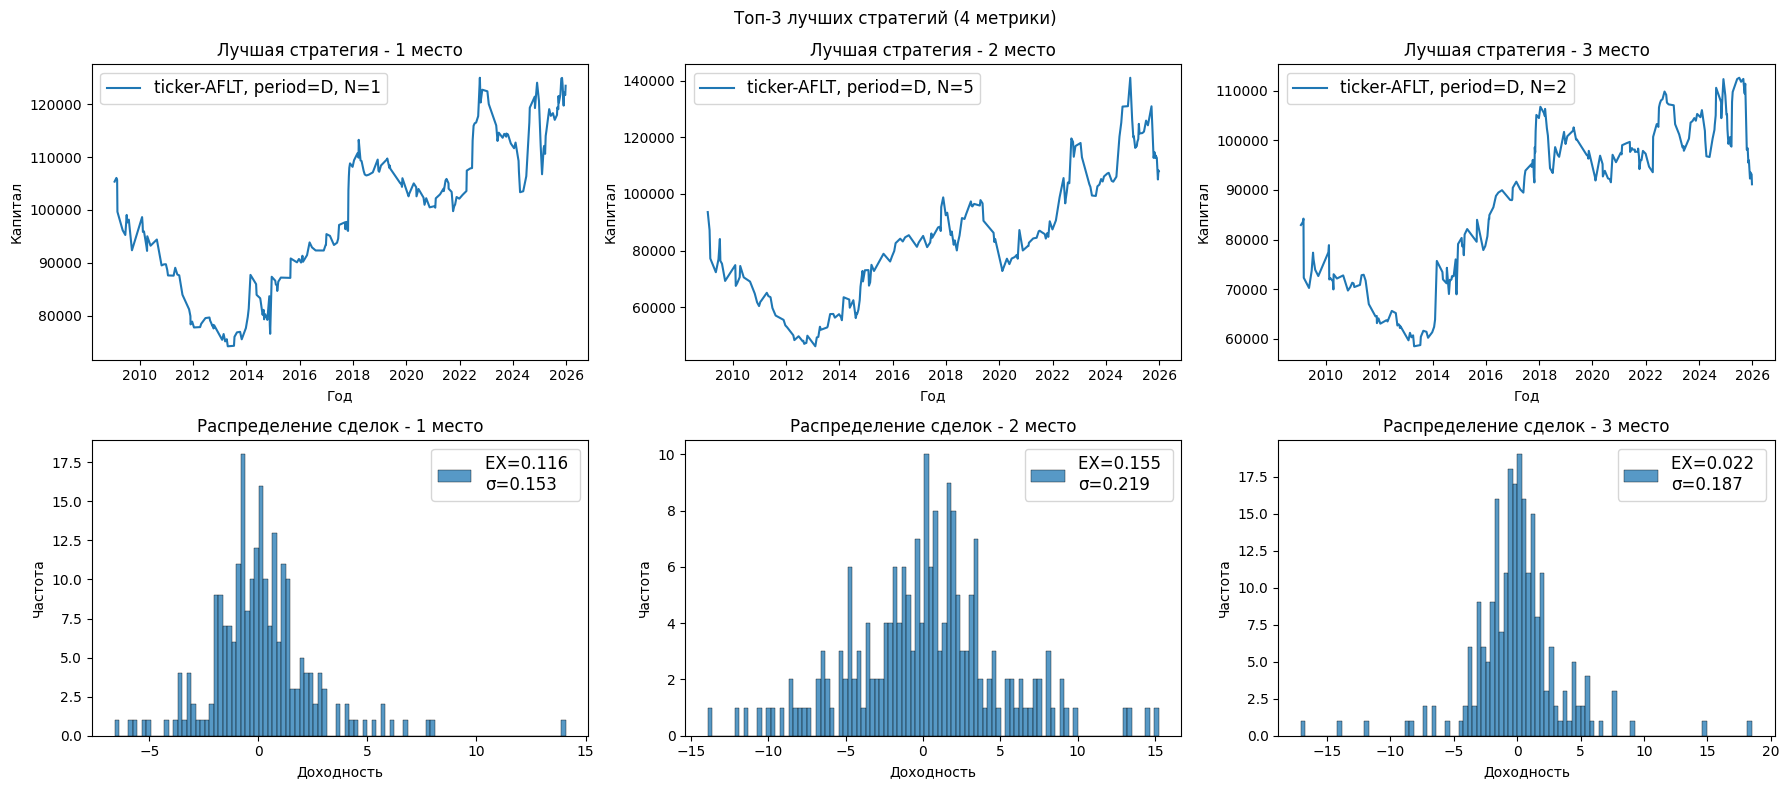

,ticker,strategy name,period,N,count of trades,profit factor,mean profit (%),mean loss (%),profit/loss ratio,max drawdown (%),total percent return,R2,win_rate
0,AFLT,bearish_engulfing_pattern,D,1,236,1.156,1.7,-1.5,1.13,18.7,23.49,0.68,0.50
1,AFLT,bearish_engulfing_pattern,D,5,196,1.090,3.4,-3.8,0.90,27.0,7.99,0.73,0.55
2,AFLT,bearish_engulfing_pattern,D,2,236,1.020,2.3,-2.2,1.04,20.2,-8.85,0.72,0.50
3,AFLT,bearish_engulfing_pattern,D,6,182,1.079,3.9,-4.1,0.95,29.1,2.83,0.62,0.53
4,AFLT,bearish_engulfing_pattern,D,7,174,1.060,4.3,-4.1,1.05,31.5,-6.06,0.57,0.51


In [8]:
# Функция для первичного отбора стратегий
def compare_strategies(data):
    """Функция предназначена для сравнения полученных стратегий и выявления наилучших претендентов
    для дальнейшего анализа.

    Args:
        data (pd.DataFrame): Датафрейм с результатами стратегий
    Returns:
        data (pd.DaraFrame): Возвращаем отфильтрованный датафрейм со результатами стратегии на всех тайфреймах.
    """
    # Фильтрация стратегий
    data = data[(data['count of trades'] > 100) & (data['profit factor'] > 1) & (data['R2'] > 0.5)] # Ограничение по количеству сделок
    if data.shape[0] != 0:
        data['profit factor rank'] = data['profit factor'].rank() # Больше лучше
        data['R2 rank'] = data['R2'].rank() # Больше лучше
        data['profit/loss ratio rank'] = data['profit/loss ratio'].rank() # Больше лучше
        data['max drawdown rank'] = data['max drawdown (%)'].rank(ascending=False) # Меньше лучше
        data['best model'] = data['profit factor rank'] + data['R2 rank'] + data['profit/loss ratio rank'] + data['max drawdown rank']
        
        # Построение графиков 3 лучших стратегий
        
        data.sort_values('best model', ascending=False, inplace=True, ignore_index=True)
        if data.shape[0] >= 3:    
            # График
            fig, axes = plt.subplots(2, 3, figsize=(18, 8))
            plt.suptitle('Топ-3 лучших стратегий (4 метрики)')
            
            # Первые 3 графика
            sns.lineplot(data.loc[0, 'capital curve net'], ax=axes[0, 0], label=f'ticker-{data.loc[0, 'ticker']}, period={data.loc[0, 'period']}, N={data.loc[0, 'N']}');
            sns.lineplot(data.loc[1, 'capital curve net'], ax=axes[0, 1], label=f'ticker-{data.loc[1, 'ticker']}, period={data.loc[1, 'period']}, N={data.loc[1, 'N']}');
            sns.lineplot(data.loc[2, 'capital curve net'], ax=axes[0, 2], label=f'ticker-{data.loc[2, 'ticker']}, period={data.loc[2, 'period']}, N={data.loc[2, 'N']}');
            axes[0, 0].legend(fontsize=12)
            axes[0, 1].legend(fontsize=12)
            axes[0, 2].legend(fontsize=12)
            
            axes[0, 0].set_title('Лучшая стратегия - 1 место')
            axes[0, 1].set_title('Лучшая стратегия - 2 место')
            axes[0, 2].set_title('Лучшая стратегия - 3 место')
            axes[0, 0].set_ylabel('Капитал')
            axes[0, 1].set_ylabel('Капитал')
            axes[0, 2].set_ylabel('Капитал')
            axes[0, 0].set_xlabel('Год')
            axes[0, 1].set_xlabel('Год')
            axes[0, 2].set_xlabel('Год')
            
            # Вторые 3 графика
            sns.histplot(data.loc[0, 'profit percent net'] * 100, ax=axes[1, 0], bins=100, 
                            label=f'EX={np.round(np.mean(data.loc[0, "profit percent net"]) * 100, 3)} \nσ={np.round(np.sqrt(np.std(data.loc[0, "profit percent net"])),3)}');
            sns.histplot(data.loc[1, 'profit percent net'] * 100, ax=axes[1, 1], bins=100,
                            label=f'EX={np.round(np.mean(data.loc[1, "profit percent net"]) * 100, 3)} \nσ={np.round(np.sqrt(np.std(data.loc[1, "profit percent net"])),3)}');
            sns.histplot(data.loc[2, 'profit percent net'] * 100, ax=axes[1, 2], bins=100,
                            label=f'EX={np.round(np.mean(data.loc[2, "profit percent net"]) * 100, 3)} \nσ={np.round(np.sqrt(np.std(data.loc[2, "profit percent net"])),3)}');
            axes[1, 0].legend(fontsize=12)
            axes[1, 1].legend(fontsize=12)
            axes[1, 2].legend(fontsize=12)
                
            axes[1, 0].set_title('Распределение сделок - 1 место')
            axes[1, 1].set_title('Распределение сделок - 2 место')
            axes[1, 2].set_title('Распределение сделок - 3 место')
            axes[1, 0].set_ylabel('Частота')
            axes[1, 1].set_ylabel('Частота')
            axes[1, 2].set_ylabel('Частота')
            axes[1, 0].set_xlabel('Доходность')
            axes[1, 1].set_xlabel('Доходность')
            axes[1, 2].set_xlabel('Доходность')
                
            plt.tight_layout()
            plt.show()
            data_new = data[['ticker', 'strategy name', 'period', 'N', 'count of trades',
            'profit factor', 'mean profit (%)', 'mean loss (%)', 'profit/loss ratio', 'max drawdown (%)', 'total percent return', 'R2', 'win_rate']]
            display(data_new.head(10))       
            return data
        else:
            data_new = data[['ticker', 'strategy name', 'period', 'N', 'count of trades',
            'profit factor', 'mean profit (%)', 'mean loss (%)', 'profit/loss ratio', 'max drawdown (%)', 'total percent return', 'R2', 'win_rate']]
            display(data_new.head(10))
            return data  
            
    else:
        print('ХОРОШИХ СТРАТЕГИЙ НЕТ')
    
res = compare_strategies(aflt_result_strategies)